In [78]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict, Annotated
import operator
import os
os.environ["LANGCHAIN_PROJECT"] = "parallel_workflow"
from pydantic import BaseModel

In [79]:
class llm_state(TypedDict):

    prompt:str
    outline:str
    blog:str
    language_feedback: str
    analysis_feedback: str
    individual_score : Annotated[list[int],operator.add]
    overall_feedback : str
    average_score : int

In [80]:
class feedback_output(BaseModel):
    feedback: str
    score: int

In [81]:
class feedback_output(BaseModel):
    feedback: str
    score: int

In [82]:
from langchain_openai import ChatOpenAI
from dotenv import load_dotenv
load_dotenv(verbose=True)

True

In [83]:
model1 = ChatOpenAI(model='gpt-4o-mini')

In [84]:
model2= ChatOpenAI(model="gpt-4o-mini")
feedback_model = model2.with_structured_output(feedback_output)

In [85]:
graph = StateGraph(llm_state)


In [86]:
from langchain_core.output_parsers import StrOutputParser

parser=StrOutputParser()

In [87]:
def create_outline(state: llm_state):

    initial_prompt = state['prompt']
    outline_prompt = f" create a detailed outline for writing a blog on this topic {initial_prompt}"
    outline = parser.invoke(model1.invoke(outline_prompt))
    return {"outline": outline}


In [88]:
def create_blog(state:llm_state):
    outline = state['outline']
    blog_prompt = f" create a detailed blog for this topic {outline}"
    blog = parser.invoke(model1.invoke(blog_prompt))

    return {"blog" : blog}


In [89]:
def lang_feed(llm_state:llm_state):

    prompt = f" give a deatailed feeback on the language of this blog {llm_state["blog"]}"

    feedback_output = feedback_model.invoke(prompt)

    return {"language_feedback": feedback_output.feedback, "individual_score": [feedback_output.score]}



In [90]:
def analyst_feed(llm_state:llm_state):

    prompt = f" give a deatailed feeback on the anyalsis of the paticular topic this blog is about {llm_state["blog"]}"

    feedback_output = feedback_model.invoke(prompt)

    return {"analysis_feedback": feedback_output.feedback, "individual_score": [feedback_output.score]}



In [91]:
def final_eval(llmstate:llm_state):
    prompt = f"based on these two feedback give a final evalution to the blog. first is the language feedbacck of this blog {llmstate['language_feedback']} and the next is the ability of the blog to anaylse the subject it was written on {llmstate["analysis_feedback"]}"

    overall_feedback = model1.invoke(prompt).content

    #averaging the scores
    average_score = sum(llmstate["individual_score"])/len(llmstate["individual_score"])

    return {"overall_feedback": overall_feedback, "average_score": average_score}

In [92]:
graph.add_node('create_outline', create_outline)
graph.add_node('create_blog', create_blog)
graph.add_node('language_feedback', lang_feed)
graph.add_node('anaylsis_feedback', analyst_feed)
graph.add_node("final_evaluation", final_eval)




In [93]:
graph.add_edge(START,"create_outline")
graph.add_edge("create_outline","create_blog")
graph.add_edge("create_blog","language_feedback")
graph.add_edge("create_blog","anaylsis_feedback")
graph.add_edge("language_feedback","final_evaluation")
graph.add_edge("anaylsis_feedback","final_evaluation")
graph.add_edge("final_evaluation",END)

In [94]:
workflow = graph.compile()

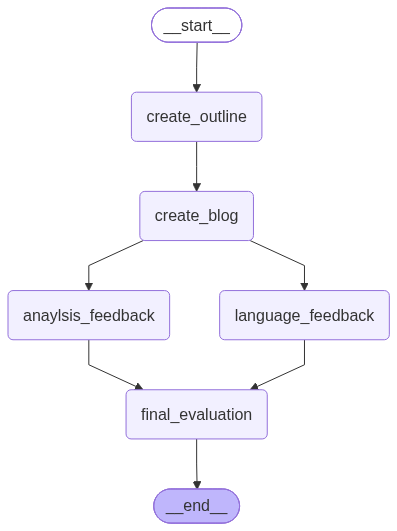

In [95]:
from IPython.display import Image
Image(workflow.get_graph().draw_mermaid_png())

In [96]:
initial_state = {"prompt": "what is the horoscope for pisces in auagust? how are my chances for a admit from university of koblenz."}

final_state = workflow.invoke(initial_state)








In [97]:

print(final_state
      )

{'prompt': 'what is the horoscope for pisces in auagust? how are my chances for a admit from university of koblenz.', 'outline': '**Outline for the Blog: "What is the Horoscope for Pisces in August? How Are My Chances for Admission from University of Koblenz?"**\n\n**I. Introduction**\n   - A. Brief introduction to astrology and its significance\n   - B. Overview of Pisces as a zodiac sign\n   - C. Importance of horoscopes for guidance and personal insights\n   - D. Mention the dual focus of the blog: horoscope insights for Pisces and admission prospects at the University of Koblenz.\n\n**II. Understanding the Pisces Zodiac Sign**\n   - A. Dates and general characteristics \n      1. Birthdates (February 19 - March 20)\n      2. Symbol: The Fish\n      3. Ruling Planet: Neptune\n      4. Element: Water\n   - B. Traits of Pisces \n      1. Intuitive and emotional\n      2. Artistic and imaginative\n      3. Compassionate and empathetic\n      4. Challenges (e.g., tendency toward escapis